# Statistics

In statistics there are two different versions of calculating the standard deviation. This is a short walk through of both.

In [1]:
nb.10 <- c(409, 400, 406, 399, 402, 406, 401, 403, 401, 403, 398, 403, 407, 402, 401, 399, 400, 401, 405, 402,
           408, 399, 399, 402, 399, 397, 407, 401, 399, 401, 403, 400, 410, 401, 407, 423, 406, 406, 402, 405,
           405, 409, 399, 402, 407, 406, 413, 409, 404, 402, 404, 406, 407, 405, 411, 410, 410, 410, 401, 402,
           404, 405, 392, 407, 406, 404, 403, 408, 404, 407, 412, 406, 409, 400, 408, 404, 401, 404, 408, 406,
           408, 406, 401, 412, 393, 437, 418, 415, 404, 401, 401, 407, 412, 375, 409, 406, 398, 406, 403, 404)

In [2]:
# Mean deviation
md <- function(x) { sum(abs(x - mean(x))) / length(x) }
# Full population version of standard deviation. The version that is incorporated in R is called SD+.
# You can convert the SD+ value to SD by multiplying by sqrt((N-1)/N)*SD+
sd.pop1 <- function(x) { sqrt((length(x)-1)/length(x))*sd(x) }
sd.pop2 <- function(x) { sqrt(sum((x - mean(x))^2) / length(x) ) }

In [3]:
md(nb.10)
sd.pop1(nb.10)
sd.pop2(nb.10)
sd(nb.10)

[1] 4.2136

[1] 6.434431

[1] 6.434431

[1] 6.466846

[1] 0.6836311


Call:
lm(formula = y ~ x)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.8768 -0.6138 -0.1395  0.5394  2.3462 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.03769    0.09699  -0.389    0.698    
x            0.99894    0.10773   9.273 4.58e-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9628 on 98 degrees of freedom
Multiple R-squared:  0.4674,	Adjusted R-squared:  0.4619 
F-statistic: 85.99 on 1 and 98 DF,  p-value: 4.583e-15


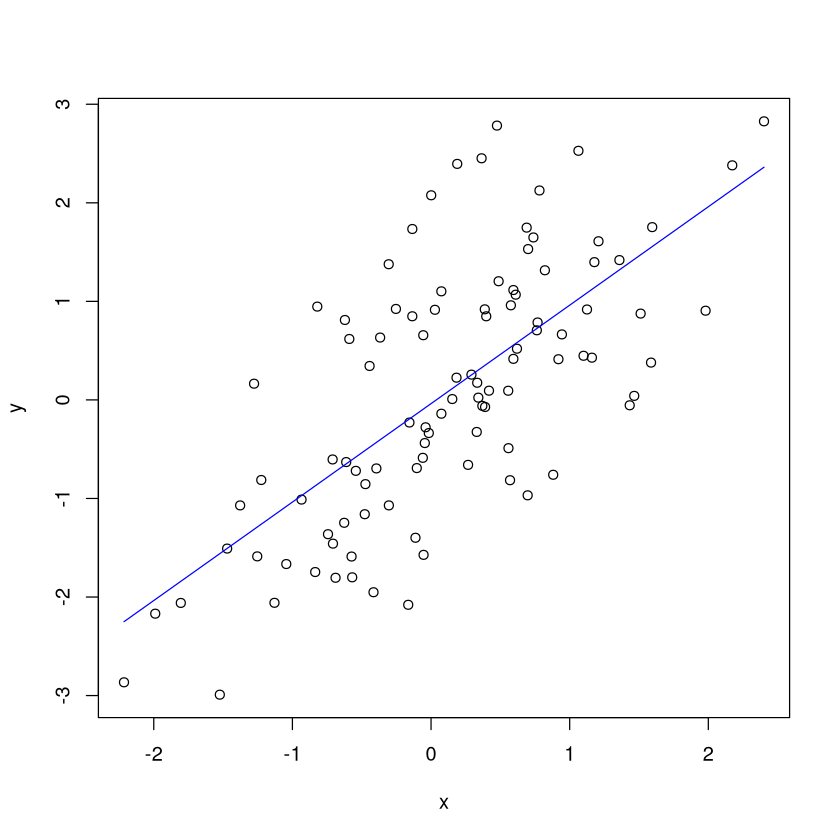

In [4]:
set.seed(1)
x <- rnorm(100)
y <- x + rnorm(100, sd=1)
cor(x, y)
plot(x, y)
fit <- lm(y ~ x)
lines(x,fit$fit, col="blue")
summary(fit)

In [5]:
# Again population version of standard deviation
sd.pop <- function(x) { sqrt(sum((x-mean(x))^2)/length(x)) }

In [6]:
# Population version of converting to standard units.
su.pop <- function(x) { (x - mean(x))/sd.pop(x) }

In [7]:
# Correlation using population version.
cor.pop <- function(x, y) { mean(su.pop(x) * su.pop(y)) }

[1] 0.6836311

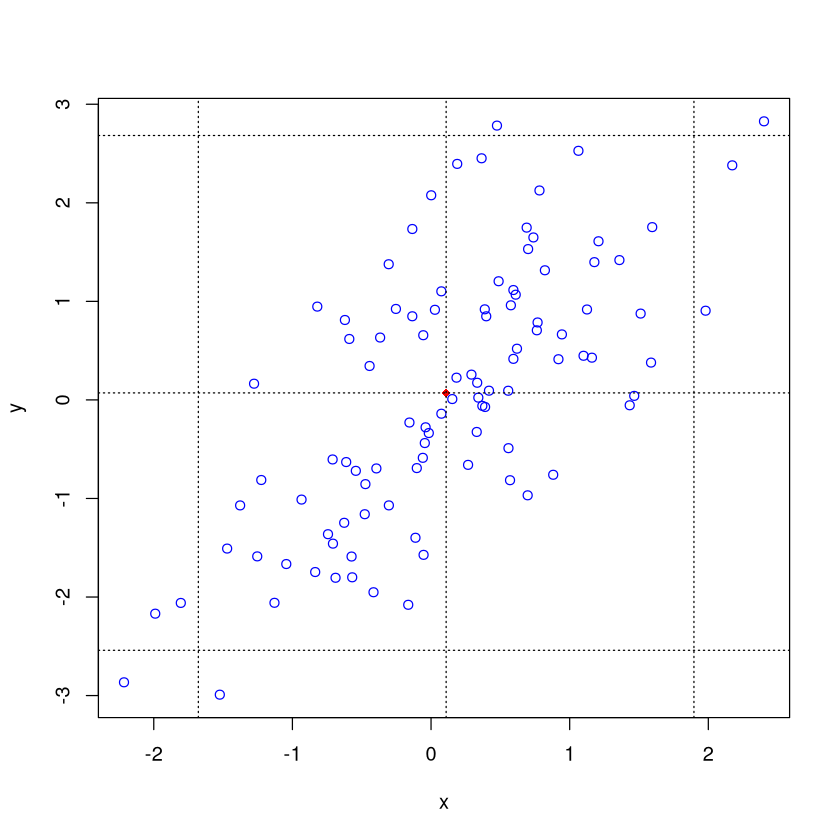

In [8]:
cor.pop(x,y)
x.mean <- mean(x)
y.mean <- mean(y)
x.sd <- sd.pop(x)
y.sd <- sd.pop(y)
plot(x, y, col="blue")
points(x.mean,y.mean, pch=18, col="red")
abline(v=x.mean,lty=3)
abline(v=x.mean+2*x.sd, lty=3)
abline(v=x.mean-2*x.sd, lty=3)
abline(h=y.mean, lty=3)
abline(h=y.mean+2*y.sd, lty=3)
abline(h=y.mean-2*y.sd, lty=3)

In [9]:
x <- c(1, 3, 4, 5, 7)
y <- c(5, 9, 7, 1, 13)
(x.su <- su.pop(x))
(y.su <- su.pop(y))
x.su * y.su
cor.pop(x,y)

[1] -1.5 -0.5  0.0  0.5  1.5

[1] -0.5  0.5  0.0 -1.5  1.5

[1]  0.75 -0.25  0.00 -0.75  2.25

[1] 0.4

---

# Regression
_See References_  
We are using the following data set:
NHANES - 2003-4  

We are using the data set from the National Center for Health Statistics. The data set comes from NHANES 2003-2004 and is the height and weight for men between the ages of 18&ndash;24.

From this data we need to look at the demographics, specifically the [gender](https://wwwn.cdc.gov/Nchs/Nhanes/2003-2004/DEMO_C.htm#RIAGENDR) and [age](https://wwwn.cdc.gov/Nchs/Nhanes/2003-2004/DEMO_C.htm#RIDAGEEX). The variable for gender is `RIAGENDR` and the variable for age is `RIDAGEEX`.
Males are coded `1` and for age. The variable is in months. For 18&ndash;24 that would be 216&ndash;288. The data set is in `xpt` format so we need to use the `haven` library and the `read_xpt()` function.

In [10]:
require(haven)
#demo <- read_xpt(url('https://wwwn.cdc.gov/Nchs/Nhanes/2003-2004/DEMO_C.XPT'))
demo <- read_xpt('./Saves/DEMO_C.XPT')
males <- demo[demo$RIAGENDR == 1 & demo$RIDAGEEX >= 216 & demo$RIDAGEEX <= 288,]$SEQN

Loading required package: haven



We will be studying the height and weight. In the data set height is in centimeters and weight is in kilograms. We need to convert to inches and pounds repsectively.

In [11]:
#bm <- read_xpt(url('https://wwwn.cdc.gov/Nchs/Nhanes/2003-2004/BMX_C.XPT'))
bm <- read_xpt('./Saves/BMX_C.XPT')
x <- na.omit(bm[bm$SEQN %in% males,c('BMXHT','BMXWT')])
# Convert to inches and pounds
ht <- x$BMXHT*.4
wt <- x$BMXWT*2.2

Below are the summary statistics. We will heavily round the values for simplicity.

In [12]:
old.digits = getOption("digits")
options(digits=1)
cat("Summary Statistics:\n\t", 
    "average height:", (m.ht <- mean(ht)), "inches,  SD:", (sd.ht <- sd(ht)), "inches\n\t",
    "average weight:", (m.wt <- mean(wt)), "pounds,  SD:", (sd.wt <- sd(wt)), "pounds\n\t\n\t",
    "correlation (r):", (cor.men <- cor(ht, wt)))
options(digits=old.digits)

Summary Statistics:
	 average height: 71 inches,  SD: 3 inches
	 average weight: 176 pounds,  SD: 47 pounds
	
	 correlation (r): 0.4

Now we will draw Figure 1 found in the book on page 159. Below is a scatter plot of the data. It is not exact as in the book, but it is close.
Below shows the differences:

* In the book the number of observations are 471 men ages 18&ndash;24.
* Below is the same (using variable `RIDAGEEX` as the age), but we have 452 observations.

__DEFINITION__  
Associated with each increase of one SD in $x$ there is an increase of only $r$ SDs in $y$, on the average.

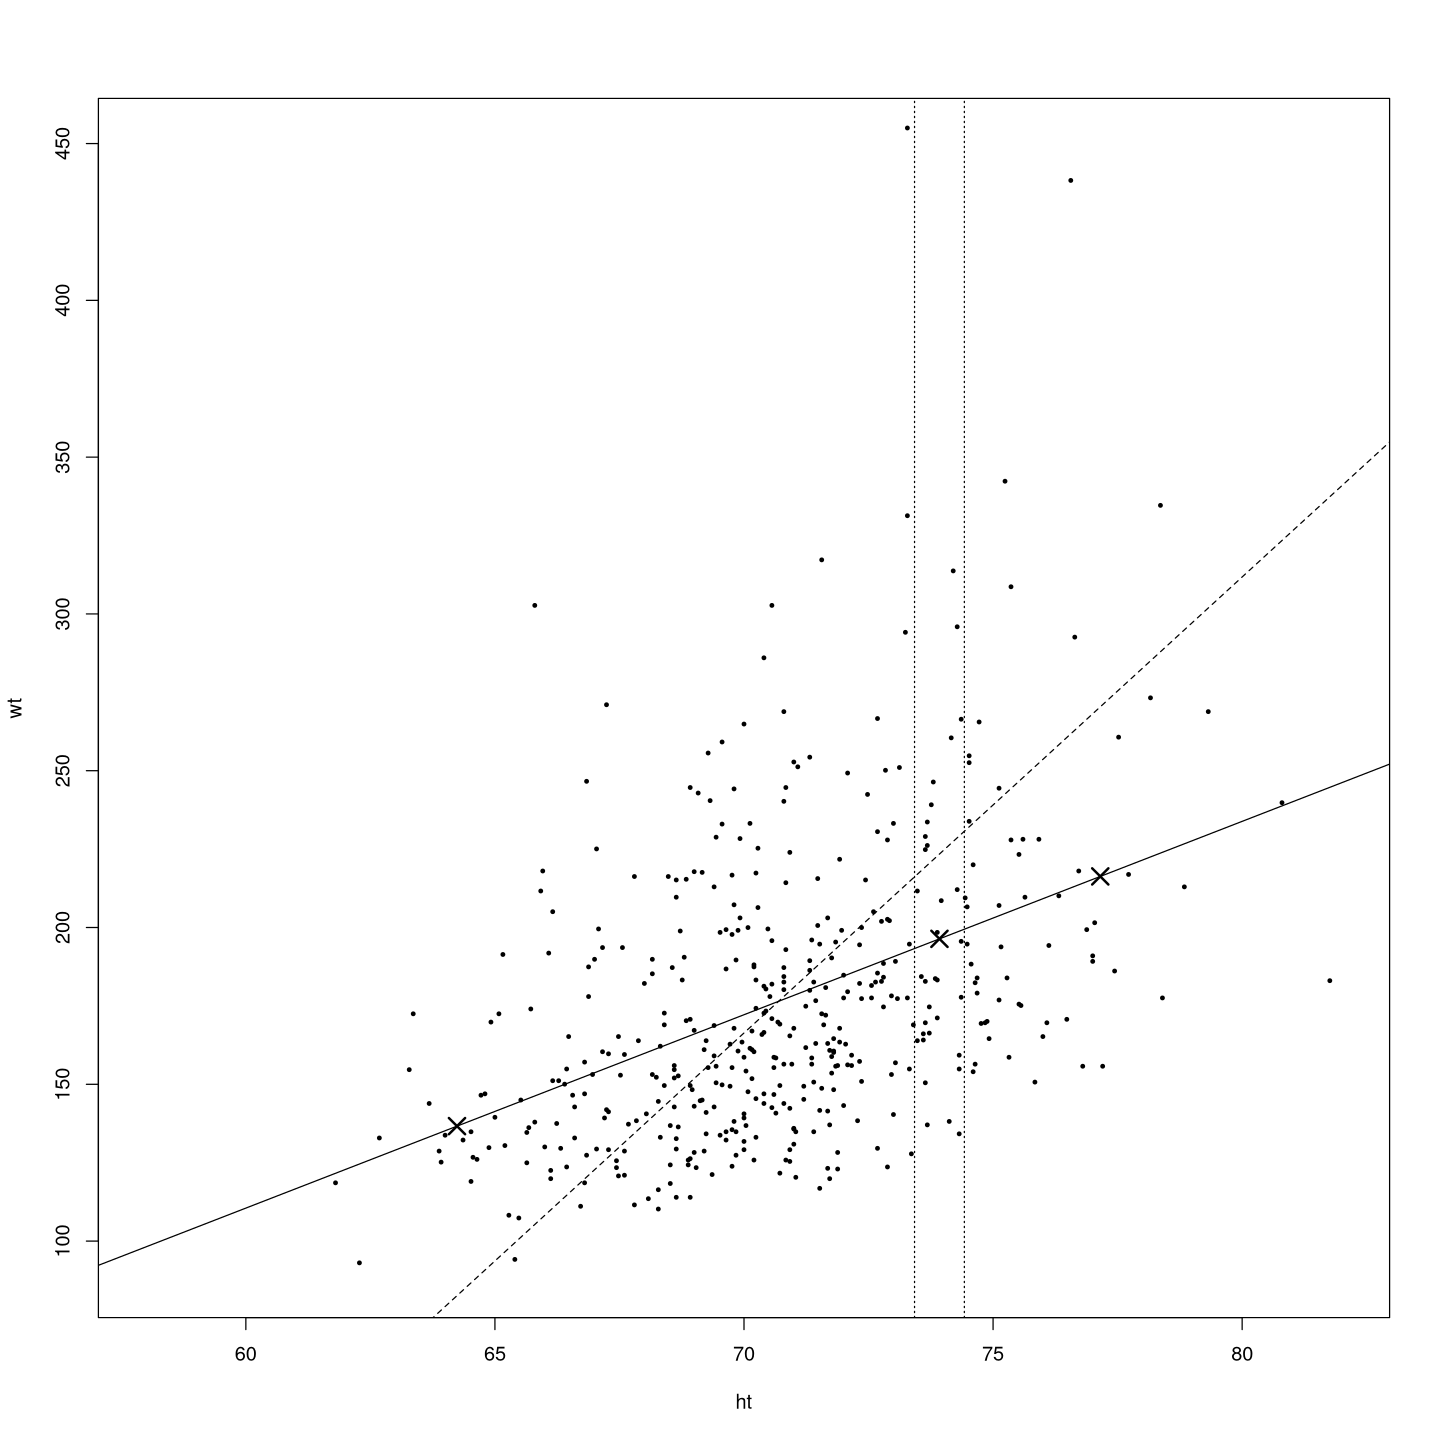

In [13]:
old.repr.plot.width=getOption("repr.plot.width")
old.repr.plot.height=getOption("repr.plot.height")
options(repr.plot.width=12, repr.plot.height=12)

# This plots the scatterplot of height vs. weight of all 452 men ages 18-24
plot(ht, wt, pch=20, cex=.6, xlim=c(58, 82), ylim=c(90, 450))

# This prouces the vertical strip that represents men who are one SD above average in height.
abline(v=(m.ht+sd.ht-.5), lty=3)
abline(v=(m.ht+sd.ht+.5), lty=3)

# The build out the regression line (solid line). We build the regression line using the regression method
regression.points <- data.frame(
    x=c(m.ht-2*sd.ht, m.ht+sd.ht, m.ht+2*sd.ht),
    y=c(m.wt-2*cor.men*sd.wt, m.wt+cor.men*sd.wt, m.wt+2*cor.men*sd.wt))
points(x=regression.points$x, y=regression.points$y, pch=4, cex=1.8, lwd=2)
regression.slope <- (regression.points$y[2] - regression.points$y[1]) / (regression.points$x[2] - regression.points$x[1])
regression.intercept <- regression.points$y[1] - regression.slope * regression.points$x[1]
abline(a=regression.intercept, b=regression.slope)

# This plots 1-1 SD height vs SD weight (dashed line).
sd.points <- data.frame(
    x=c(m.ht-sd.ht, m.ht, m.ht+sd.ht),
    y=c(m.wt-sd.wt, m.wt, m.wt+sd.wt))
sd.slope <- (sd.points$y[2] - sd.points$y[1]) / (sd.points$x[2] - sd.points$x[1])
sd.intercept <- sd.points$y[1] - sd.slope * sd.points$x[1]
abline(a=sd.intercept, b=sd.slope, lty=2)

options(repr.plot.width=old.repr.plot.width, repr.plot.height=old.repr.plot.height)

Interesting questions:  

__1.__ If a man is one SD above average in height, what would be the estimated weight of that person?  
__ANSWER:__ The correlation between height and weight is $0.4$. This means that person's weight would be $0.4$ SDs above the average weight.

In [14]:
old.digits = getOption("digits")
options(digits=1)
cat("The estimated weight of the man 1 SD above average height is:", cor(ht, wt) * sd(wt) + mean(wt), "lb.")
options(digits=old.digits)

The estimated weight of the man 1 SD above average height is: 196 lb.

In [15]:
rm(list=ls())

---

## The Graph of Averages
page 162  


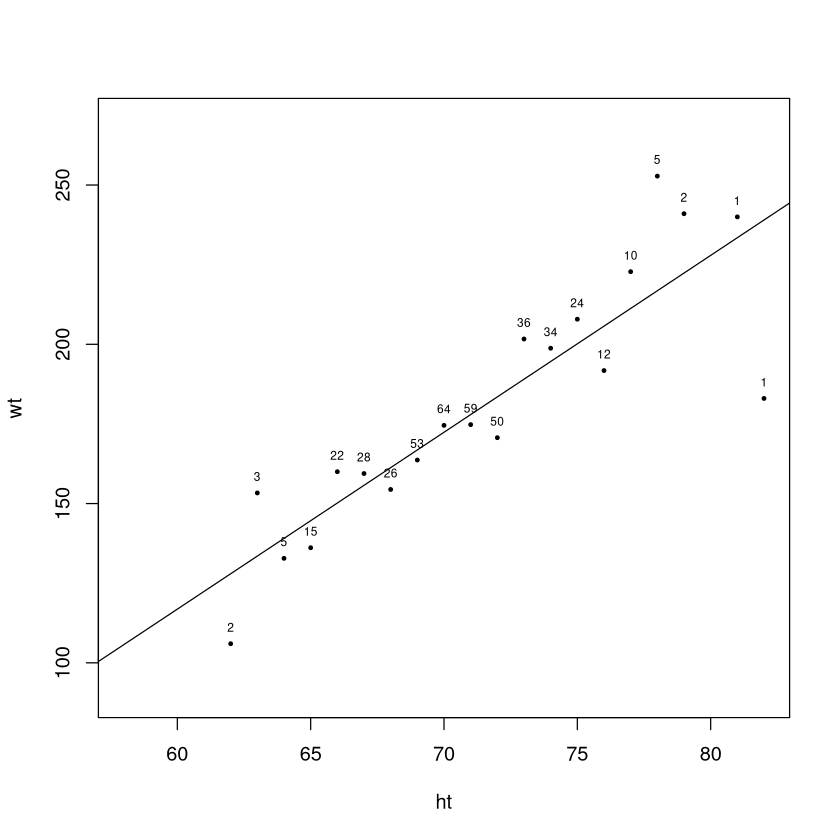

In [16]:
# Data
require(haven)
demo <- read_xpt('./Saves/DEMO_C.XPT')
males <- demo[demo$RIAGENDR == 1 & demo$RIDAGEEX >= 216 & demo$RIDAGEEX <= 288,]$SEQN
bm <- read_xpt('./Saves/BMX_C.XPT')
x <- na.omit(bm[bm$SEQN %in% males,c('BMXHT','BMXWT')])
old.digits = getOption("digits")
options(digits=1)
df <- data.frame(height=round(x$BMXHT*.4), weight=round(x$BMXWT*2.2))

# The Graph of averages calculation (mean and count)
agg <- aggregate(weight ~ height, data=df, FUN=function(x){c(mean=mean(x), count=length(x))})
ht <- agg$height
m.ht <- mean(ht)
sd.ht <- sd(ht)
wt <- agg$weight[,1]
m.wt <- mean(wt)
sd.wt <- sd(wt)
cor.avg <- cor(ht, wt)
cnt <- agg$weight[,2]
plot(x=ht,y=wt, pch=20, cex=.6, xlim=c(58, 82), ylim=c(90, 270))
text(x=ht,y=wt, labels=cnt, pos=3, cex=.6)
regression.points <- data.frame(
    x=c(m.ht-2*sd.ht, m.ht+sd.ht, m.ht+2*sd.ht),
    y=c(m.wt-2*cor.avg*sd.wt, m.wt+cor.avg*sd.wt, m.wt+2*cor.avg*sd.wt))
regression.slope <- (regression.points$y[2] - regression.points$y[1]) / (regression.points$x[2] - regression.points$x[1])
regression.intercept <- regression.points$y[1] - regression.slope * regression.points$x[1]
abline(a=regression.intercept, b=regression.slope)
options(digits=old.digits)

---

__References__  
- Freedman, David, et al. “Chapter 10 Regression.” Statistics, Norton, New York, 2014.